# 🛒 E-Commerce Sales Analysis

Bu proje, bir e-ticaret satış verisi üzerinde keşifsel veri analizi (EDA) yaparak satış performansı, müşteri davranışları ve kârlılık analizlerini incelemektedir.

## Amaç
- Satış trendlerini analiz etmek
- En başarılı ürün kategorilerini belirlemek
- Kârlılık faktörlerini incelemek
- İşletme için anlamlı çıkarımlar yapmak

## 📚 Kullanılan Kütüphaneler
-import pandas as pd

-import numpy as np

-import matplotlib.pyplot as plt

-import seaborn as sns

-import warnings

-warnings.filterwarnings("ignore")

## 📂 Dataset Yükleme
df = pd.read_csv("SampleSuperstore.csv")

df.head()

## 🔍 Veri Keşfi
-df.shape

-df.info()

-df.isnull().sum()

## 📊 Genel Satış ve Kâr Analizi
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Toplam Satış:", total_sales)
print("Toplam Kâr:", total_profit)

## 🏷️ Kategori Bazlı Analiz
## 📉 İndirim ve Kârlılık İlişkisi

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [19]:
## veri kontrolü
## kaç satır var
## hangi sütunlar var
## eksik veri var mı

In [7]:
df.shape

(9994, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [11]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [21]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [25]:
## sütun isimleri hangi analizleri yapacağımızı görelim 
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [27]:
## toplam satış ve toplam kar
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("Toplam Satış:", total_sales)
print("Toplam Kâr:", total_profit)

Toplam Satış: 2297200.8603000003
Toplam Kâr: 286397.0217


In [35]:
## yüzde alalım
profit_margin = (total_profit / total_sales) * 100
print(profit_margin)

12.467217240315604


In [29]:
## kategori bazlı satış analizi
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

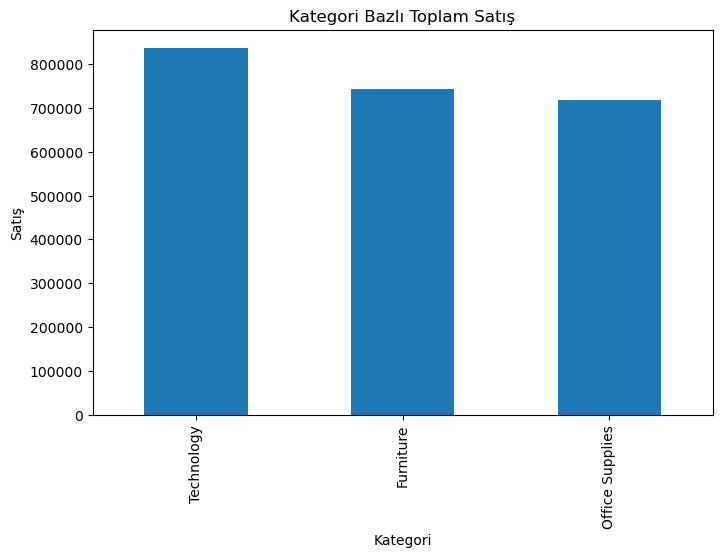

In [31]:
## grafik oluşturalım
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Kategori Bazlı Toplam Satış")
plt.xlabel("Kategori")
plt.ylabel("Satış")

plt.show()

In [39]:
## kategori analizi
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [41]:
## kar analizi
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

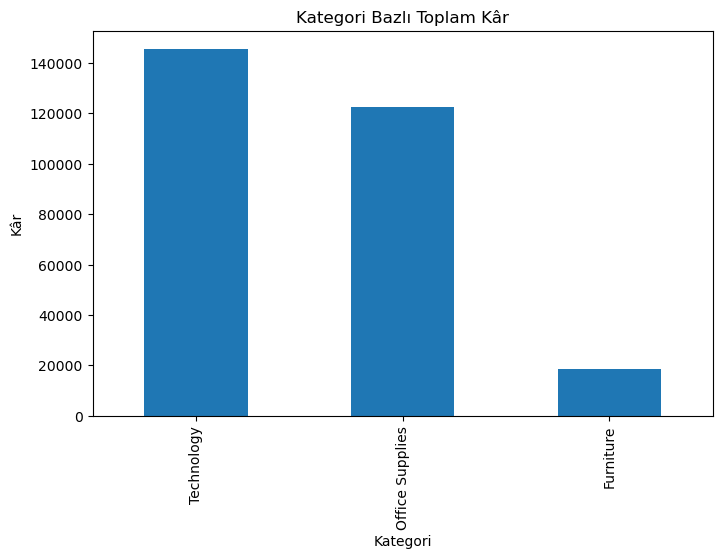

In [43]:
plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Kategori Bazlı Toplam Kâr")
plt.xlabel("Kategori")
plt.ylabel("Kâr")

plt.show()

In [45]:
df.groupby("Discount")["Profit"].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

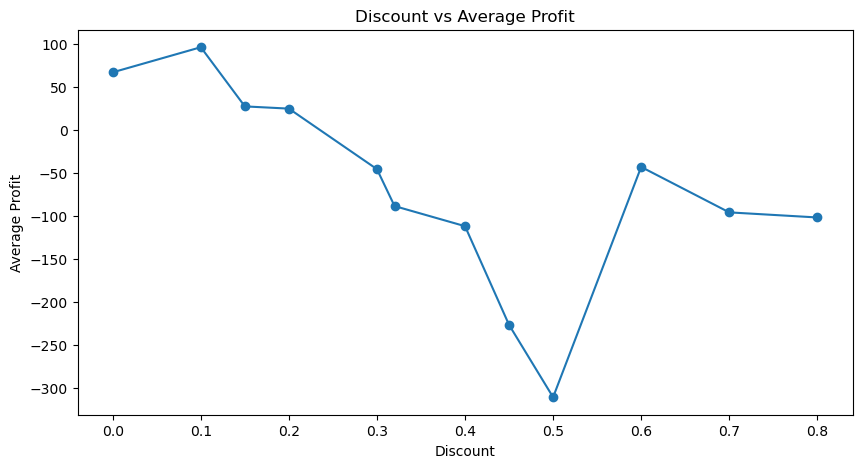

In [47]:
discount_profit = df.groupby("Discount")["Profit"].mean()

plt.figure(figsize=(10,5))

discount_profit.plot(kind="line", marker="o")

plt.title("Discount vs Average Profit")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

In [49]:
## en çok satan ürünler
top_products = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

top_products

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

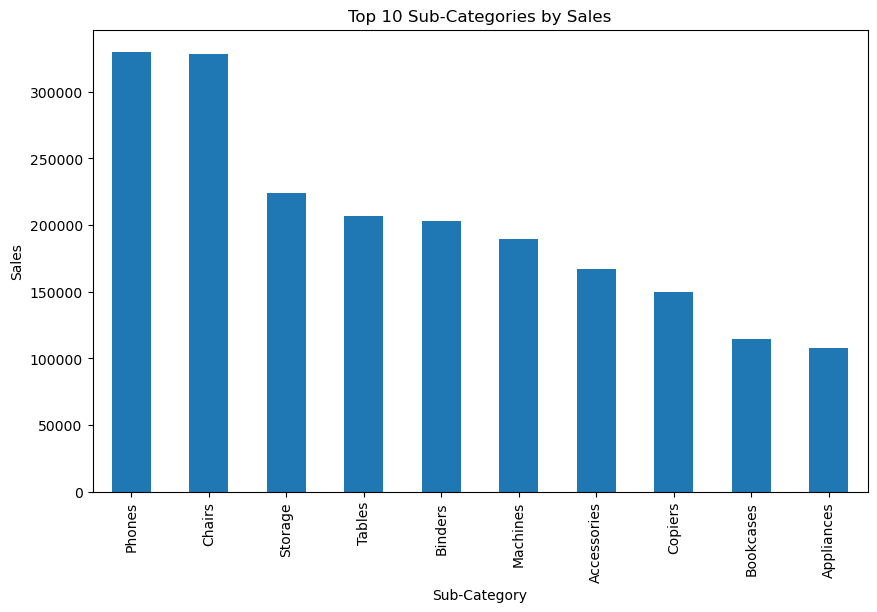

In [51]:
## görselleştirelim
plt.figure(figsize=(10,6))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.show()

In [53]:
##  En kârlı ve zarar ettiren alt kategoriler
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

sub_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [57]:
sub_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [59]:
## Bölge bazlı satış ve kâr analizi
region_analysis = df.groupby("Region")[["Sales","Profit"]].sum()

region_analysis

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


# 📌 Sonuçlar

- Technology kategorisi en yüksek satış ve kâr değerine sahiptir.
- Copiers en fazla kâr sağlayan alt kategoridir.
- Yüksek indirim oranları kârlılığı olumsuz etkilemektedir.
- West bölgesi en başarılı performansa sahip bölgedir.
- Bazı yüksek satış yapan ürün grupları düşük veya negatif kâr üretmektedir.